In [1]:
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv("cayuga_hrrr_2015_2024_merged.csv")
df = df.drop(columns=["dateTime"])

predicting_column = "lake_effect_flag"
X = df.drop(columns=predicting_column)
y = df[predicting_column]

X_train, X_test, y_train, y_test = train_test_split(X, y) # 80 20 

clf = LazyClassifier(verbose=0,ignore_warnings=True)

models,predictions = clf.fit(X_train, X_test, y_train, y_test)
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
NearestCentroid,0.676058,0.755838,0.832078,0.772330,0.952637,0.676058,0.271384
DecisionTreeClassifier,0.933039,0.588005,0.588005,0.933421,0.933806,0.933039,0.099237
GaussianNB,0.948200,0.582915,0.828532,0.942091,0.937335,0.948200,0.020962
ExtraTreeClassifier,0.933039,0.572114,0.572114,0.932346,0.931662,0.933039,0.023379
Perceptron,0.910802,0.546065,0.657824,0.918258,0.926205,0.910802,0.029059
CatBoostClassifier,0.959065,0.538022,0.867050,0.943876,0.945209,0.959065,4.609145
KNeighborsClassifier,0.955527,0.537621,0.720084,0.941876,0.936082,0.955527,0.058309
XGBClassifier,0.956791,0.531057,0.859480,0.941729,0.937239,0.956791,1.649244
BaggingClassifier,0.956412,0.530859,0.743704,0.941502,0.936360,0.956412,0.443393


In [2]:
import pandas as pd
import numpy as np

# Load both datasets
ith = pd.read_csv("../DataAssembly/ith_2015_2025_winter_with_lake_effect.csv")
ith["valid"] = pd.to_datetime(ith["valid"], format="%Y-%m-%d %H:%M:%S")

hrrr = pd.read_csv("cayuga_hrrr_2015_2024_merged.csv")
hrrr["dateTime"] = pd.to_datetime(hrrr["dateTime"], format="%Y-%m-%d %H:%M:%S")

# ITH weather columns to carry over (drop metadata/string/categorical cols)
ITH_WEATHER_COLS = [
    "tmpf", "dwpf", "relh", "drct", "sknt", "p01i",
    "alti", "mslp", "vsby", "gust", "feel", "snowdepth", "skyl1",
]

# Coerce 'M' and other non-numeric values to NaN (vectorized in C, much faster than .replace)
for col in ITH_WEATHER_COLS:
    ith[col] = pd.to_numeric(ith[col], errors="coerce")

# --- Vectorized merge ---
# Round each ITH observation to its nearest hour and compute offset
ith["nearest_hour"] = ith["valid"].dt.round("h")
ith["offset_min"] = (ith["valid"] - ith["nearest_hour"]).abs().dt.total_seconds() / 60

# Keep only observations within ±15 min of any hour
ith_near = ith[ith["offset_min"] <= 15].copy()

# Per hour: lake_effect_flag = 1 if ANY nearby obs is flagged
flag_by_hour = ith_near.groupby("nearest_hour")["lake_effect_flag"].max().rename("lake_effect_flag")

# Per hour: take the closest observation for weather features
ith_sorted = ith_near.sort_values("offset_min")
closest_by_hour = ith_sorted.groupby("nearest_hour")[ITH_WEATHER_COLS].first()
closest_by_hour.columns = [f"ith_{c}" for c in closest_by_hour.columns]

# Build merged: use HRRR hours as the spine
hrrr_indexed = hrrr.set_index("dateTime")

merged = (
    hrrr_indexed[["meanDeltaT", "meanRH850", "meanDeltaWindShear"]]
    .join(closest_by_hour, how="left")
    .join(flag_by_hour, how="left")
)

# Drop HRRR hours that have no ITH observation within ±15 min (~797 expected)
n_before = len(merged)
merged = merged.dropna(subset=["lake_effect_flag"])
merged["lake_effect_flag"] = merged["lake_effect_flag"].astype(int)
merged = merged.reset_index().rename(columns={"index": "dateTime"})

print(f"HRRR rows:         {len(hrrr)}")
print(f"Merged rows:       {len(merged)}")
print(f"Skipped (no ITH):  {n_before - len(merged)}")
print(f"Lake effect hours: {merged['lake_effect_flag'].sum()}")
merged.head()


HRRR rows:         31659
Merged rows:       31209
Skipped (no ITH):  450
Lake effect hours: 1259


,dateTime,meanDeltaT,meanRH850,meanDeltaWindShear,ith_tmpf,ith_dwpf,ith_relh,ith_drct,ith_sknt,ith_p01i,ith_alti,ith_mslp,ith_vsby,ith_gust,ith_feel,ith_snowdepth,ith_skyl1,lake_effect_flag
0,2015-01-01 01:00:00,3.566150,85.489770,76.086650,18.14,5.0,55.83,230.0,12.0,0.0,30.10,1021.2,10.0,NaN,4.36,NaN,NaN,0
1,2015-01-01 02:00:00,5.078141,69.505630,71.693870,18.14,5.0,55.83,220.0,11.0,0.0,30.08,1020.4,10.0,NaN,4.95,NaN,NaN,0
2,2015-01-01 03:00:00,5.908094,64.459465,81.427270,19.00,5.0,53.71,220.0,13.0,0.0,30.05,1019.3,10.0,NaN,4.97,NaN,NaN,0
3,2015-01-01 04:00:00,5.598954,61.512726,85.109825,19.00,5.0,53.71,220.0,12.0,0.0,30.03,1018.7,10.0,NaN,5.51,NaN,6500.0,0
4,2015-01-01 05:00:00,5.853695,65.226040,90.718750,19.00,5.0,53.71,220.0,10.0,0.0,30.00,1017.9,10.0,18.0,6.72,NaN,6000.0,0


In [3]:
merged

,dateTime,meanDeltaT,meanRH850,meanDeltaWindShear,ith_tmpf,ith_dwpf,ith_relh,ith_drct,ith_sknt,ith_p01i,ith_alti,ith_mslp,ith_vsby,ith_gust,ith_feel,ith_snowdepth,ith_skyl1,lake_effect_flag
0,2015-01-01 01:00:00,3.566150,85.489770,76.086650,18.14,5.0,55.83,230.0,12.0,0.0,30.10,1021.2,10.0,NaN,4.36,NaN,NaN,0
1,2015-01-01 02:00:00,5.078141,69.505630,71.693870,18.14,5.0,55.83,220.0,11.0,0.0,30.08,1020.4,10.0,NaN,4.95,NaN,NaN,0
2,2015-01-01 03:00:00,5.908094,64.459465,81.427270,19.00,5.0,53.71,220.0,13.0,0.0,30.05,1019.3,10.0,NaN,4.97,NaN,NaN,0
3,2015-01-01 04:00:00,5.598954,61.512726,85.109825,19.00,5.0,53.71,220.0,12.0,0.0,30.03,1018.7,10.0,NaN,5.51,NaN,6500.0,0
4,2015-01-01 05:00:00,5.853695,65.226040,90.718750,19.00,5.0,53.71,220.0,10.0,0.0,30.00,1017.9,10.0,18.0,6.72,NaN,6000.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31204,2024-03-31 20:00:00,13.736076,77.292710,37.908257,49.00,31.0,49.65,300.0,10.0,0.0,29.94,1014.5,10.0,NaN,44.29,NaN,5000.0,0
31205,2024-03-31 21:00:00,12.776357,75.581810,48.589180,49.00,30.0,47.68,330.0,7.0,0.0,29.94,1014.3,10.0,NaN,45.50,NaN,5000.0,0
31206,2024-03-31 22:00:00,10.889955,71.004950,59.635838,49.00,30.0,47.68,310.0,11.0,0.0,29.94,1014.4,10.0,NaN,43.95,NaN,NaN,0
31207,2024-03-31 23:00:00,8.497204,61.366960,95.522890,45.00,30.0,55.43,330.0,6.0,0.0,29.94,1014.6,10.0,NaN,41.19,NaN,NaN,0


In [4]:
# Export merged to CSV (includes dateTime — run before the cell that drops it)
merged.to_csv("cayuga_ith_merged.csv", index=False)
print(f"Exported {len(merged)} rows to cayuga_ith_merged.csv")

Exported 31209 rows to cayuga_ith_merged.csv


In [5]:
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split
import pandas as pd

merged = merged.drop(columns=["dateTime"])

predicting_column = "lake_effect_flag"
X = merged.drop(columns=predicting_column)
y = merged[predicting_column]

X_train, X_test, y_train, y_test = train_test_split(X, y) # 80 20 

clf = LazyClassifier(verbose=0,ignore_warnings=True)

models,predictions = clf.fit(X_train, X_test, y_train, y_test)
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
NearestCentroid,0.837498,0.880952,0.941081,0.884443,0.964694,0.837498,0.075158
GaussianNB,0.876970,0.874850,0.939881,0.909442,0.963933,0.876970,0.033383
BernoulliNB,0.910163,0.848239,0.941192,0.929999,0.962231,0.910163,0.065909
CatBoostClassifier,0.977829,0.834867,0.984315,0.977413,0.977086,0.977829,8.995610
LGBMClassifier,0.977316,0.825197,0.983996,0.976735,0.976317,0.977316,0.267055
XGBClassifier,0.974881,0.819228,0.982325,0.974516,0.974201,0.974881,3.193381
ExplainableBoostingClassifier,0.974881,0.817660,0.983321,0.974474,0.974130,0.974881,23.360704
LabelSpreading,0.970652,0.801354,NaN,0.970536,0.970424,0.970652,25.945734
LabelPropagation,0.970396,0.801220,NaN,0.970326,0.970257,0.970396,9.823311


In [6]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestCentroid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import balanced_accuracy_score, classification_report

# --- Rebuild X/y from merged (re-run prior cell if merged is not in scope) ---
_df = merged.drop(columns=["dateTime"], errors="ignore")
X = _df.drop(columns=["lake_effect_flag"])
y = _df["lake_effect_flag"]

# --- Pipeline: impute → scale → NearestCentroid ---
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # median robust to outlier-heavy cols
    ("scaler",  StandardScaler()),
    ("nc",      NearestCentroid()),
])

param_grid = {
    "nc__metric":            ["euclidean", "manhattan"],
    "nc__shrink_threshold":  [None, 0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = GridSearchCV(
    pipe,
    param_grid,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
search.fit(X, y)

print(f"\nBest params:           {search.best_params_}")
print(f"Best balanced acc (CV): {search.best_score_:.4f}")

# --- Evaluate best model with full CV report ---
from sklearn.model_selection import cross_val_predict
best = search.best_estimator_
y_pred = cross_val_predict(best, X, y, cv=cv)
print("\nClassification report (stratified 5-fold CV predictions):")
print(classification_report(y, y_pred, target_names=["no lake effect", "lake effect"]))
print(f"Balanced accuracy: {balanced_accuracy_score(y, y_pred):.4f}")


Fitting 5 folds for each of 16 candidates, totalling 80 fits


/home/f00l2/miniconda3/envs/py311/lib/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ith_snowdepth']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/f00l2/miniconda3/envs/py311/lib/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ith_snowdepth']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/f00l2/miniconda3/envs/py311/lib/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ith_snowdepth']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/f00l2/miniconda3/envs/py311/lib/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ith_snowdepth']. At least one non-missing 


Best params:           {'nc__metric': 'manhattan', 'nc__shrink_threshold': None}
Best balanced acc (CV): 0.8844

Classification report (stratified 5-fold CV predictions):
                precision    recall  f1-score   support

no lake effect       1.00      0.84      0.91     29950
   lake effect       0.19      0.93      0.32      1259

      accuracy                           0.84     31209
     macro avg       0.59      0.88      0.61     31209
  weighted avg       0.96      0.84      0.89     31209

Balanced accuracy: 0.8844


/home/f00l2/miniconda3/envs/py311/lib/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ith_snowdepth']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/f00l2/miniconda3/envs/py311/lib/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ith_snowdepth']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/f00l2/miniconda3/envs/py311/lib/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ith_snowdepth']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/f00l2/miniconda3/envs/py311/lib/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ith_snowdepth']. At least one non-missing 

In [11]:
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split
import pandas as pd

# Filter to physically plausible lake-effect conditions:
#   temp <= 34°F, wind >= 5 kt, wind from W/NW/N (250–360 or 0–30°)
mergedFiltered = merged[
    (merged["ith_tmpf"] <= 34) &
    (merged["ith_sknt"] >= 5) &
    ((merged["ith_drct"] >= 250) | (merged["ith_drct"] <= 30))
].copy()

print(f"mergedFiltered rows:       {len(mergedFiltered)}")
print(f"Lake effect hours (filt):  {mergedFiltered['lake_effect_flag'].sum()}")

_df = mergedFiltered.drop(columns=["dateTime"], errors="ignore")
predicting_column = "lake_effect_flag"
X = _df.drop(columns=predicting_column)
y = _df[predicting_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

clf = LazyClassifier(verbose=0, ignore_warnings=True)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)
models

mergedFiltered rows:       8287
Lake effect hours (filt):  1175


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
LGBMClassifier,0.924228,0.804253,0.964248,0.920276,0.920115,0.924228,0.197451
XGBClassifier,0.922780,0.792597,0.961630,0.917829,0.918456,0.922780,3.674873
CatBoostClassifier,0.922780,0.792597,0.963778,0.917829,0.918456,0.922780,3.628855
RandomForestClassifier,0.929537,0.791157,0.962776,0.923479,0.927496,0.929537,0.960399
ExplainableBoostingClassifier,0.917471,0.789482,0.954726,0.913018,0.912483,0.917471,27.500407
ExtraTreesClassifier,0.929054,0.786821,0.964532,0.922581,0.927366,0.929054,0.589789
LabelSpreading,0.900579,0.786327,NaN,0.898886,0.897586,0.900579,2.397568
LabelPropagation,0.899614,0.785761,NaN,0.898053,0.896820,0.899614,1.480927
GaussianNB,0.789093,0.781714,0.858922,0.813866,0.869502,0.789093,0.023845


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

_df = merged.drop(columns=["dateTime"], errors="ignore")
X = _df.drop(columns=["lake_effect_flag"])
y = _df["lake_effect_flag"]

# Standard 80/20 split (mixed train), then keep only LE rows in test
X_train, X_test_full, y_train, y_test_full = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
le_mask = y_test_full == 1
X_test, y_test = X_test_full[le_mask], y_test_full[le_mask]
print(f"Train: {len(X_train)} rows (mixed)  |  Test: {len(X_test)} rows (lake-effect only)")

classifiers = [
    ("LGBMClassifier",          make_pipeline(SimpleImputer(), LGBMClassifier(verbose=-1, random_state=42))),
    ("XGBClassifier",           make_pipeline(SimpleImputer(), XGBClassifier(verbosity=0, random_state=42))),
    ("CatBoostClassifier",      make_pipeline(SimpleImputer(), CatBoostClassifier(verbose=0, random_state=42))),
    ("RandomForestClassifier",  make_pipeline(SimpleImputer(), RandomForestClassifier(n_jobs=-1, random_state=42))),
    ("ExtraTreesClassifier",    make_pipeline(SimpleImputer(), ExtraTreesClassifier(n_jobs=-1, random_state=42))),
    ("BaggingClassifier",       make_pipeline(SimpleImputer(), BaggingClassifier(random_state=42))),
    ("DecisionTreeClassifier",  make_pipeline(SimpleImputer(), DecisionTreeClassifier(random_state=42))),
    ("KNeighborsClassifier",    make_pipeline(SimpleImputer(), KNeighborsClassifier(n_jobs=-1))),
    ("AdaBoostClassifier",      make_pipeline(SimpleImputer(), AdaBoostClassifier(random_state=42))),
    ("LogisticRegression",      make_pipeline(SimpleImputer(), StandardScaler(), LogisticRegression(max_iter=1000))),
    ("GaussianNB",              make_pipeline(SimpleImputer(), StandardScaler(), GaussianNB())),
    ("NearestCentroid",         make_pipeline(SimpleImputer(), StandardScaler(), NearestCentroid())),
]

rows = []
for name, clf in classifiers:
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1] if hasattr(clf[-1], "predict_proba") else None
    rows.append({
        "Model":      name,
        "Accuracy":   accuracy_score(y_test, y_pred),
        "Precision":  precision_score(y_test, y_pred, zero_division=0),
        "Recall":     recall_score(y_test, y_pred, zero_division=0),
        "F1 Score":   f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC":    roc_auc_score(y_test, y_prob) if y_prob is not None else float("nan"),
    })

results_le = pd.DataFrame(rows).set_index("Model").sort_values("Recall", ascending=False)
results_le

Train: 24967 rows (mixed)  |  Test: 252 rows (lake-effect only)


/home/f00l2/miniconda3/envs/py311/lib/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ith_snowdepth']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/home/f00l2/miniconda3/envs/py311/lib/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ith_snowdepth']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/home/f00l2/miniconda3/envs/py311/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/f00l2/miniconda3/envs/py311/lib/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ith_snowdepth']. At least one non-missing value is needed for imputation with strategy='mean'.
  warn

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
NearestCentroid,0.904762,1.0,0.904762,0.950000,NaN
GaussianNB,0.861111,1.0,0.861111,0.925373,NaN
XGBClassifier,0.662698,1.0,0.662698,0.797136,NaN
LGBMClassifier,0.646825,1.0,0.646825,0.785542,NaN
CatBoostClassifier,0.642857,1.0,0.642857,0.782609,NaN
RandomForestClassifier,0.619048,1.0,0.619048,0.764706,NaN
ExtraTreesClassifier,0.611111,1.0,0.611111,0.758621,NaN
BaggingClassifier,0.599206,1.0,0.599206,0.749380,NaN
DecisionTreeClassifier,0.587302,1.0,0.587302,0.740000,NaN


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

# Reuse same train split, keep only non-LE rows in test
_df = merged.drop(columns=["dateTime"], errors="ignore")
X = _df.drop(columns=["lake_effect_flag"])
y = _df["lake_effect_flag"]

X_train, X_test_full, y_train, y_test_full = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
non_le_mask = y_test_full == 0
X_test, y_test = X_test_full[non_le_mask], y_test_full[non_le_mask]
print(f"Train: {len(X_train)} rows (mixed)  |  Test: {len(X_test)} rows (non-lake-effect only)")

rows = []
for name, clf in classifiers:   # classifiers fitted in previous cell
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1] if hasattr(clf[-1], "predict_proba") else None
    rows.append({
        "Model":      name,
        "Accuracy":   accuracy_score(y_test, y_pred),
        "Precision":  precision_score(y_test, y_pred, pos_label=0, zero_division=0),
        "Recall":     recall_score(y_test, y_pred, pos_label=0, zero_division=0),
        "F1 Score":   f1_score(y_test, y_pred, pos_label=0, zero_division=0),
        "ROC AUC":    roc_auc_score(y_test, y_prob) if y_prob is not None else float("nan"),
    })

results_non_le = pd.DataFrame(rows).set_index("Model").sort_values("Recall", ascending=False)
results_non_le

Train: 24967 rows (mixed)  |  Test: 5990 rows (non-lake-effect only)


/home/f00l2/miniconda3/envs/py311/lib/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ith_snowdepth']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/home/f00l2/miniconda3/envs/py311/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/f00l2/miniconda3/envs/py311/lib/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['ith_snowdepth']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/home/f00l2/miniconda3/envs/py311/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/f00l2/miniconda3/envs/py311/lib/pyth

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
ExtraTreesClassifier,0.994992,1.0,0.994992,0.997490,NaN
LogisticRegression,0.994157,1.0,0.994157,0.997070,NaN
RandomForestClassifier,0.993322,1.0,0.993322,0.996650,NaN
BaggingClassifier,0.993155,1.0,0.993155,0.996566,NaN
AdaBoostClassifier,0.991653,1.0,0.991653,0.995809,NaN
CatBoostClassifier,0.991319,1.0,0.991319,0.995641,NaN
LGBMClassifier,0.991152,1.0,0.991152,0.995556,NaN
XGBClassifier,0.990150,1.0,0.990150,0.995051,NaN
KNeighborsClassifier,0.987813,1.0,0.987813,0.993869,NaN


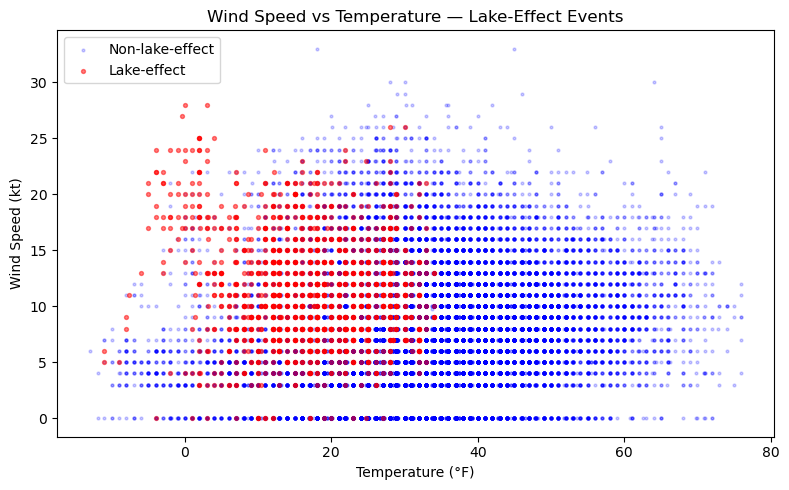

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

_df = merged.dropna(subset=["ith_tmpf", "ith_sknt"])
le_mask = _df["lake_effect_flag"] == 1

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(_df.loc[~le_mask, "ith_tmpf"], _df.loc[~le_mask, "ith_sknt"],
           color="blue", alpha=0.2, s=4, label="Non-lake-effect")
ax.scatter(_df.loc[le_mask,  "ith_tmpf"], _df.loc[le_mask,  "ith_sknt"],
           color="red",  alpha=0.5, s=8, label="Lake-effect")

ax.set_xlabel("Temperature (°F)")
ax.set_ylabel("Wind Speed (kt)")
ax.set_title("Wind Speed vs Temperature — Lake-Effect Events")
ax.legend()
plt.tight_layout()
plt.show()

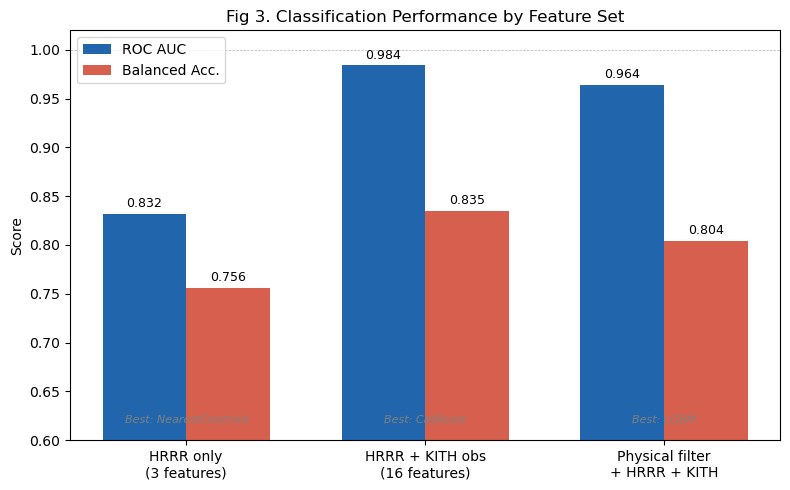

In [1]:
import matplotlib.pyplot as plt
import numpy as np

labels = [
    "HRRR only\n(3 features)",
    "HRRR + KITH obs\n(16 features)",
    "Physical filter\n+ HRRR + KITH",
]
best_models  = ["NearestCentroid", "CatBoost", "LGBM"]
roc_auc      = [0.832, 0.984, 0.964]
balanced_acc = [0.756, 0.835, 0.804]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, roc_auc,      width, label="ROC AUC",       color="#2166ac")
bars2 = ax.bar(x + width/2, balanced_acc, width, label="Balanced Acc.", color="#d6604d")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

for i, model in enumerate(best_models):
    ax.text(x[i], 0.615, f"Best: {model}", ha="center", va="bottom",
            fontsize=8, color="gray", style="italic")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0.60, 1.02)
ax.set_ylabel("Score")
ax.set_title("Fig 3. Classification Performance by Feature Set")
ax.legend()
ax.axhline(y=1.0, color="black", linewidth=0.5, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("fig3_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()